In [1]:
!pwd

/home/dayn/analysis/macrohetest/dev


In [26]:
# Standard library imports
import os
import warnings

# Third-party imports
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from tqdm.auto import tqdm  # Note: You might want to choose between tqdm or tqdm.auto

# Visualization imports
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
from matplotlib import gridspec
import seaborn as sns
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

# Local imports
from macrohet import visualise, colours

# Setting visualization defaults
plt.rcParams['font.family'] = 'Nimbus Sans'
plt.rcParams['font.size'] = 14
visualise.set_plotting_defaults()
expanded_piyg = colours.expanded_piyg

# Constants
meters_per_pixel = 1.4949402023919043E-07
micrometers_per_pixel = meters_per_pixel*1E6

Helvetica not found. Using Nimbus Sans font.
Default plotting aesthetic loaded.


In [2]:
def replace_ytick_labels(ax, old_label, new_label):
    """
    Replace y-axis tick labels in a given matplotlib Axes object.
    
    Parameters:
    ax (matplotlib.axes.Axes): The axes on which to replace y-tick labels.
    old_label (str): The label to be replaced.
    new_label (str): The new label to replace the old label with.
    """
    # Get current y-tick labels
    yticks = ax.get_yticks()
    yticklabels = [label.get_text() for label in ax.get_yticklabels()]

    # Replace the old label with the new label
    yticklabels = [new_label if label == old_label else label for label in yticklabels]

    # Set the new y-tick labels
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels)

In [4]:
df = pd.read_pickle('/Volumes/OPERA2/Nathan/macrohet_syno/results/dfs/sc_df.pkl')
# df = pd.read_pickle('/mnt/SYNO/macrohet_syno/results/dfs/sc_df.pkl')
subset_df['Video Link'] = subset_df['ID'].apply(lambda ID: f"https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/videos/{ID}_glimpse_graph.mp4")
# subset_df['Video Link'] = subset_df['ID'].apply(lambda ID: f"https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/_BLOCK_{ID}_glimpse_graph.mp4")

In [5]:
df

,ID,Time (hours),Mtb Area (µm),dMtb Area (µm),Mphi Area (µm),dMphi Area (µm),Infection Status,Initial Infection Status,Final Infection Status,x,...,Edge Status,Uptake,dMtb Area between frames (µm),Mtb Area Processed (µm),Time Model (hours),Mtb Area Model (µm),mtb_origin,Doubling Amounts,Doubling Times,r2
0,1.3.2.ND0002,0.0,0.0,0.0,4649.351562,2080.574775,NaN,False,False,107.845200,...,False,False,NaN,NaN,NaN,NaN,None,None,None,1.0
1,1.3.2.ND0002,0.5,0.0,0.0,4973.001953,2080.574775,NaN,False,False,113.264671,...,False,False,0.0,NaN,NaN,NaN,None,None,None,1.0
2,1.3.2.ND0002,1.0,0.0,0.0,4687.857910,2080.574775,NaN,False,False,116.562256,...,False,False,0.0,NaN,NaN,NaN,None,None,None,1.0
3,1.3.2.ND0002,1.5,0.0,0.0,4209.064453,2080.574775,NaN,False,False,111.890106,...,False,False,0.0,NaN,NaN,NaN,None,None,None,1.0
4,1.3.2.ND0002,2.0,0.0,0.0,4061.855225,2080.574775,False,False,False,114.113556,...,False,False,0.0,NaN,0.0,0.0,None,None,None,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1914150,9998.4.6.ND0004,59.5,0.0,NaN,261.387613,NaN,False,False,False,1034.000000,...,False,NaN,NaN,0.0,58.5,0.0,None,None,None,-1.02
1914151,9998.4.6.ND0004,60.0,0.0,NaN,275.109568,NaN,False,False,False,972.000000,...,False,NaN,NaN,0.0,59.0,0.0,None,None,None,-1.02
1914152,9998.4.6.ND0004,60.5,0.0,NaN,404.484815,NaN,False,False,False,948.000000,...,False,NaN,NaN,0.0,59.5,0.0,None,None,None,-1.02
1914153,9998.4.6.ND0004,61.0,0.0,NaN,297.055758,NaN,NaN,False,False,874.000000,...,False,NaN,NaN,0.0,NaN,NaN,None,None,None,-1.02


### Params

In [6]:
### set plotting parameters
# Input figure size in millimeters
width_mm = 280  # for example, 180 mm
height_mm = 100  # for example, 80 mm
# Convert millimeters to inches (1 inch = 25.4 mm)
width_in = width_mm / 25.4
height_in = height_mm / 25.4

### set biological parameters
# Step 1: Bin the Doubling Times into categories
bins = [0, 16, 24, float('inf')]  # Define the bins: <20, 20-24, >24
labels = ['Fast', 'Normal', 'Slow']  # Labels for each bin
# Define the desired order with CTRL at the top
strain_order = ['CTRL', 'PZA', 'INH', 'RIF']

# Antibiotic growth

In [7]:
# Prepare the subset DataFrame, filtering for WT strain or CTRL with RD1
subset_df = df[((df['Strain'] == 'WT') | ((df['Strain'] == 'RD1') & (df['Compound'] == 'CTRL'))) 
             # & (df['r2'] >= 0.8) 
             & (df['Edge Status'] == False) 
             & (df['mtb_origin'] == 'Growth')  # are we really doing this right now? or after figure 3? 
              ].drop_duplicates(subset=['ID'])

# Continue with the usual process of exploding and filtering Doubling Times
subset_df = subset_df.explode('Doubling Times')
subset_df['Doubling Times'] = pd.to_numeric(subset_df['Doubling Times'], errors='coerce')
subset_df = subset_df[subset_df['Doubling Times'].notna()]
subset_df = subset_df[subset_df['Doubling Times'] > 0]
subset_df['Mtb Strain or Drug Compound'] = subset_df.apply(
    lambda row: 'CTRL' if row['Compound'] == 'CTRL' else row['Compound'], axis=1)
subset_df['CTRL Type'] = subset_df.apply(
    lambda row: row['Strain'] if row['Compound'] == 'CTRL' else None, axis=1)
print(f'N={len(subset_df)}')

N=728


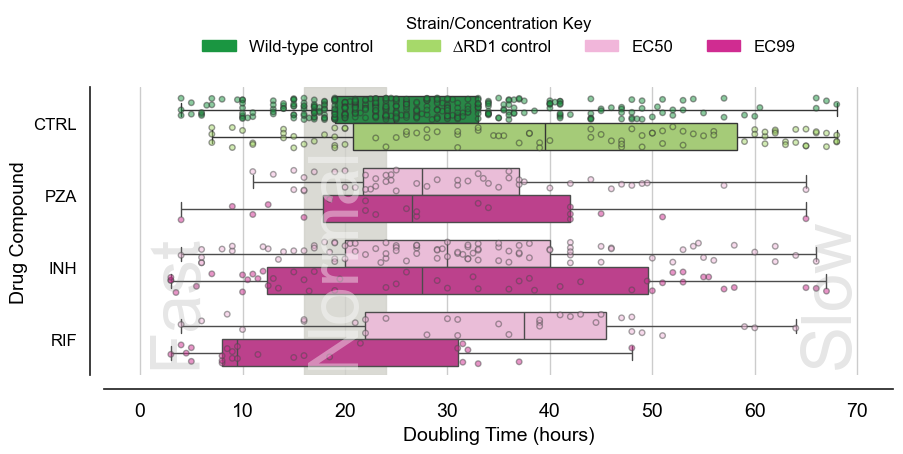

In [8]:
# Define the growth categories of the subset DataFrame
subset_df['Growth Category'] = pd.cut(subset_df['Doubling Times'], bins=bins, labels= ['Fast', 'Normal', 'Slow'], right=False)
subset_df['Mtb Strain or Drug Compound'] = subset_df.apply(
    lambda row: 'CTRL' if row['Compound'] == 'CTRL' else row['Compound'], axis=1)
subset_df['CTRL Type'] = subset_df.apply(
    lambda row: row['Strain'] if row['Compound'] == 'CTRL' else None, axis=1)

# Initialize the figure with GridSpec
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[3, 1])  # Main plot and bar chart sections

# Main Plot (left side)
ax = plt.subplot(gs[0])
for compound in ['CTRL', 'PZA', 'INH', 'RIF']:
    subset = subset_df[subset_df['Mtb Strain or Drug Compound'] == compound]
    available_concentrations = sorted(subset['Concentration'].unique())
    if compound == 'CTRL':
        sns.boxplot(
            data=subset, x="Doubling Times", y="Mtb Strain or Drug Compound", hue="CTRL Type",
            whis=[0, 100], width=.75, palette=[expanded_piyg[0], expanded_piyg[1]], ax=ax, order=strain_order
        )
        sns.stripplot(
            data=subset, x="Doubling Times", y="Mtb Strain or Drug Compound", hue="CTRL Type", size=4,
            edgecolor='auto', linewidth=1, jitter=0.3,
            palette=[expanded_piyg[0], expanded_piyg[1]], dodge=True, alpha=0.5, ax=ax, order=strain_order
        )
    else:
        palette = [expanded_piyg[4] if concentration == 'EC50' else expanded_piyg[5] for concentration in available_concentrations]
        sns.boxplot(
            data=subset, x="Doubling Times", y="Mtb Strain or Drug Compound", hue="Concentration",
            whis=[0, 100], width=.75, palette=palette, hue_order=available_concentrations, ax=ax, order=strain_order
        )
        sns.stripplot(
            data=subset, x="Doubling Times", y="Mtb Strain or Drug Compound", hue="Concentration", size=4,
            edgecolor='auto', linewidth=1, jitter=0.3,
            palette=palette, hue_order=available_concentrations, dodge=True, alpha=0.5, ax=ax, order=strain_order
        )

# Add legend and shaded regions
legend_handles = [
    mpatches.Patch(color=expanded_piyg[0], label='Wild-type control'),
    mpatches.Patch(color=expanded_piyg[1], label='∆RD1 control'),
    mpatches.Patch(color=expanded_piyg[4], label='EC50'),
    mpatches.Patch(color=expanded_piyg[5], label='EC99')
]
ax.legend(title='Strain/Concentration Key', handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4, frameon=False)
ax.axvspan(0, bins[1], color=expanded_piyg[3], alpha=0, label='Fast (<20h)')
ax.axvspan(bins[1], bins[2], color=expanded_piyg[3], alpha=0.8, label='Normal (20-28h)')
ax.axvspan(bins[2], 70, color=expanded_piyg[3], alpha=0, label='Slow (>28h)')

# Step 6: Add vertical text labels within each category region
ax.text(0+0.5, 3.2, 'Fast', fontsize=50, color='gray', alpha=0.2, ha='left', va='baseline', rotation=90)
ax.text(bins[1], 3.2, 'Normal', fontsize=50, color='white', alpha=0.4, ha='left', va='baseline', rotation=90)
ax.text(70.5, 3.2, 'Slow', fontsize=50, color='gray', alpha=0.2, ha='right', va='baseline', rotation=90)

ax.xaxis.grid(True)
replace_ytick_labels(ax, old_label='RD1', new_label='ΔRD1')

ax.set_xlabel('Doubling Time (hours)', fontsize=14)
ax.set_ylabel('Drug Compound', fontsize=14)
sns.despine(ax=ax, left=True) 
ax.tick_params(axis = 'x', left=False, labelsize = 14)

sns.despine(offset=10)

plt.tight_layout()
# plt.savefig('/mnt/SYNO/macrohet_syno/results/manuscript/f4/f4.pdf', bbox_inches='tight', dpi=314)
plt.show()


## Now integrate the bar plots to the left hand side

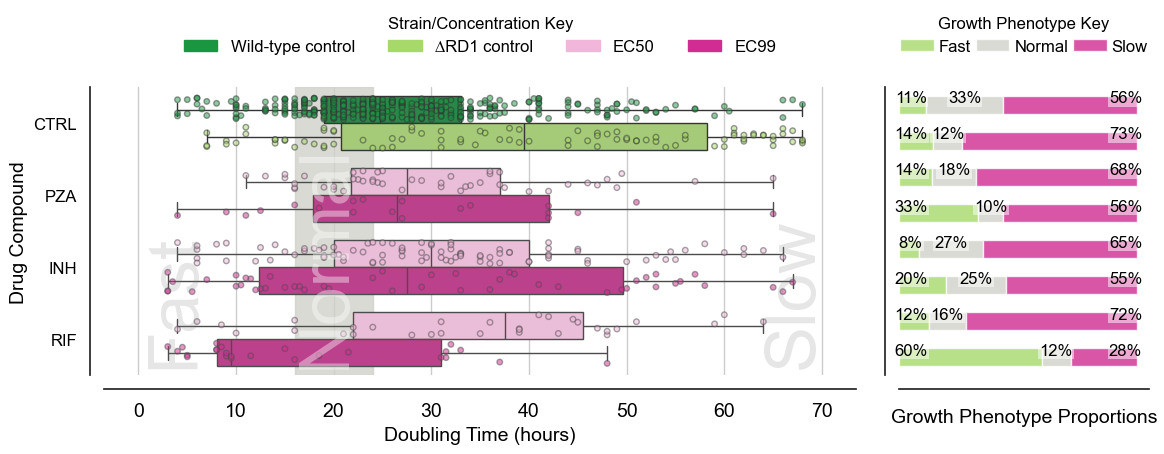

In [22]:
# Define the growth categories of the subset DataFrame
subset_df['Growth Category'] = pd.cut(subset_df['Doubling Times'], bins=bins, labels= ['Fast', 'Normal', 'Slow'], right=False)
subset_df['Mtb Strain or Drug Compound'] = subset_df.apply(
    lambda row: 'CTRL' if row['Compound'] == 'CTRL' else row['Compound'], axis=1)
subset_df['CTRL Type'] = subset_df.apply(
    lambda row: row['Strain'] if row['Compound'] == 'CTRL' else None, axis=1)

# Initialize the figure with GridSpec
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[3, 1])  # Main plot and bar chart sections

# Main Plot (left side)
ax = plt.subplot(gs[0])
for compound in ['CTRL', 'PZA', 'INH', 'RIF']:
    subset = subset_df[subset_df['Mtb Strain or Drug Compound'] == compound]
    available_concentrations = sorted(subset['Concentration'].unique())
    if compound == 'CTRL':
        sns.boxplot(
            data=subset, x="Doubling Times", y="Mtb Strain or Drug Compound", hue="CTRL Type",
            whis=[0, 100], width=.75, palette=[expanded_piyg[0], expanded_piyg[1]], ax=ax, order=strain_order
        )
        sns.stripplot(
            data=subset, x="Doubling Times", y="Mtb Strain or Drug Compound", hue="CTRL Type", size=4,
            edgecolor='auto', linewidth=1, jitter=0.3,
            palette=[expanded_piyg[0], expanded_piyg[1]], dodge=True, alpha=0.5, ax=ax, order=strain_order
        )
    else:
        palette = [expanded_piyg[4] if concentration == 'EC50' else expanded_piyg[5] for concentration in available_concentrations]
        sns.boxplot(
            data=subset, x="Doubling Times", y="Mtb Strain or Drug Compound", hue="Concentration",
            whis=[0, 100], width=.75, palette=palette, hue_order=available_concentrations, ax=ax, order=strain_order
        )
        sns.stripplot(
            data=subset, x="Doubling Times", y="Mtb Strain or Drug Compound", hue="Concentration", size=4,
            edgecolor='auto', linewidth=1, jitter=0.3,
            palette=palette, hue_order=available_concentrations, dodge=True, alpha=0.5, ax=ax, order=strain_order
        )

# Add legend and shaded regions
legend_handles = [
    mpatches.Patch(color=expanded_piyg[0], label='Wild-type control'),
    mpatches.Patch(color=expanded_piyg[1], label='∆RD1 control'),
    mpatches.Patch(color=expanded_piyg[4], label='EC50'),
    mpatches.Patch(color=expanded_piyg[5], label='EC99')
]
ax.legend(title='Strain/Concentration Key', handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4, frameon=False)
ax.axvspan(0, bins[1], color=expanded_piyg[3], alpha=0, label='Fast (<20h)')
ax.axvspan(bins[1], bins[2], color=expanded_piyg[3], alpha=0.8, label='Normal (20-28h)')
ax.axvspan(bins[2], 70, color=expanded_piyg[3], alpha=0, label='Slow (>28h)')

# Step 6: Add vertical text labels within each category region
ax.text(0+0.5, 3.2, 'Fast', fontsize=50, color='gray', alpha=0.2, ha='left', va='baseline', rotation=90)
ax.text(bins[1], 3.2, 'Normal', fontsize=50, color='white', alpha=0.4, ha='left', va='baseline', rotation=90)
ax.text(70.5, 3.2, 'Slow', fontsize=50, color='gray', alpha=0.2, ha='right', va='baseline', rotation=90)

ax.xaxis.grid(True)
replace_ytick_labels(ax, old_label='RD1', new_label='ΔRD1')

ax.set_xlabel('Doubling Time (hours)', fontsize=14)
ax.set_ylabel('Drug Compound', fontsize=14)
sns.despine(ax=ax, left=True) 
ax.tick_params(axis = 'x', left=False, labelsize = 14)
############################################# porportion plots #################################################################

# Right Plot: Stacked Bar Charts for CTRL and Antibiotics
ctrl_counts = subset_df[subset_df['Compound'] == 'CTRL'].groupby(['CTRL Type', 'Growth Category'], observed=False).size().unstack(fill_value=0)
ctrl_percentages = ctrl_counts.div(ctrl_counts.sum(axis=1), axis=0).reset_index().iloc[::-1]
ctrl_percentages['Compound'] = ctrl_percentages['CTRL Type']  # Add a common column for consistency

# Antibiotics Data: Ensure concentration is part of the final DataFrame
antibiotics_counts = subset_df[subset_df['Compound'] != 'CTRL'].groupby(
    ['Compound', 'Concentration', 'Growth Category'],  observed=False
).size().unstack(fill_value=0)

# Reset the index to include 'Compound' and 'Concentration' as columns
antibiotics_df = antibiotics_counts.reset_index()

# Normalize the antibiotics counts
antibiotics_df.set_index(['Compound', 'Concentration'], inplace=True)
antibiotics_percentages = antibiotics_df.div(antibiotics_df.sum(axis=1), axis=0).reset_index()
antibiotics_percentages['Compound'] = antibiotics_percentages['Compound'] + ' - ' + antibiotics_percentages['Concentration']

# Concatenate the two datasets
combined_data = pd.concat(
    [ctrl_percentages.set_index('Compound').drop(columns=['CTRL Type']),
     antibiotics_percentages.set_index('Compound').drop(columns=['Concentration'])],
    axis=0
)

# Normalize combined data
combined_data = combined_data.div(combined_data.sum(axis=1), axis=0).iloc[::-1]

# Plot combined data
ax2 = plt.subplot(gs[1])
combined_data.plot(
    kind='barh', stacked=True, ax=ax2, color=[expanded_piyg[1], expanded_piyg[3], expanded_piyg[5]], alpha=0.8
)
# Customizing bar chart
ax2.set_ylabel('')
ax2.legend(title='Growth Phenotype Key', bbox_to_anchor=(0.5, 1.3), loc='upper center', frameon=False, ncol = 3, 
                   handletextpad=0.3,  # Reduce space between legend marker and text
                    columnspacing=0.3)   # Reduce space between columns)
sns.despine(ax=ax2, right=True) #left = False, right = True, bottom = True)
ax2.set_ylabel('')
ax2.set_yticklabels([])
ax2.set_xticklabels([])
ax2.set_xlabel('Growth Phenotype Proportions', fontsize=14)

for i, container in enumerate(ax2.containers):
    x_positions = [0.05, 0.5, 0.95]  # Fixed x positions for left, middle, and right segments (normalized to the axis range)    
    for j, bar in enumerate(container):
        width = bar.get_width()  # Get the width of the current bar
        if width > 0:  # Only add labels for non-zero bars
            if i==1:
                x = bar.get_x() + width / 2 
            else:
                x = x_positions[i % 3]  # Assign x position based on fixed positions
            y = bar.get_y() + bar.get_height() / 2 + 0.2  # Center vertically with offset
            percentage = f"{round(width * 100):d}%"  # Format percentage rounded to an integer
            ax2.text(x, y, percentage, ha='center', va='center', fontsize=12, color='black', 
                     bbox=dict(facecolor='white', edgecolor='none', pad=1, alpha =0.5))

sns.despine(offset=10)

plt.tight_layout()
plt.show()


# Interactive F4

In [32]:
marker_colors = {
    'CTRL': expanded_piyg[0],
    'RD1': expanded_piyg[1],
    'EC50': expanded_piyg[-2],
    'EC99': expanded_piyg[-1],
    'Fast': 'white',#'rgba(0, 128, 0, 0.2)',
    'Normal': expanded_piyg[3], #'rgba(255, 255, 0, 0.4)',
    'Slow': 'white',#'rgba(255, 0, 0, 0.2)',
}
scaling_factor = 1.5
vertical_offset = 0.31
# Colors for the plot
expanded_piyg = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']  # Custom color palette
colors = {
    'WT': expanded_piyg[0],
    'RD1': expanded_piyg[1],
  'EC50': expanded_piyg[-2],
    'EC99': expanded_piyg[-1],
    'Fast': 'white',#'rgba(0, 128, 0, 0.2)',
    'Normal': expanded_piyg[3], #'rgba(255, 255, 0, 0.4)',
    'Slow': 'white',#'rgba(255, 0, 0, 0.2)',
}
# colors = {'WT':expanded_piyg[1], 'RD1':expanded_piyg[-1],   'Fast':expanded_piyg[0], 'Normal':expanded_piyg[3], 'Slow':expanded_piyg[-1]}

# Define the strain order and color palette
strain_order = ['CTRL', 'PZA', 'INH', 'RIF']  # Define the order of compounds
# reverse the order and create cat mappin
categories = subset_df['Mtb Strain or Drug Compound'].unique()[::-1]
# Update category mapping to include scaling factor
category_mapping = {category: i * scaling_factor for i, category in enumerate(categories)}

# Define vertical offsets for concentrations and CTRL types
vertical_offsets = {
    'EC50': vertical_offset,    # Shift EC50 up
    'EC99': -vertical_offset,   # Shift EC99 down
    'WT': vertical_offset,      # Shift WT slightly up
    'RD1': -vertical_offset     # Shift RD1 slightly down
}

# Legend entries configuration
legend_entries = [
    {"color": colors['WT'], "name": "Wild-type control"},
    {"color": colors['RD1'], "name": "ΔRD1 control"},
    {"color": colors['EC50'], "name": "EC50"},
    {"color": colors['EC99'], "name": "EC99"}
]


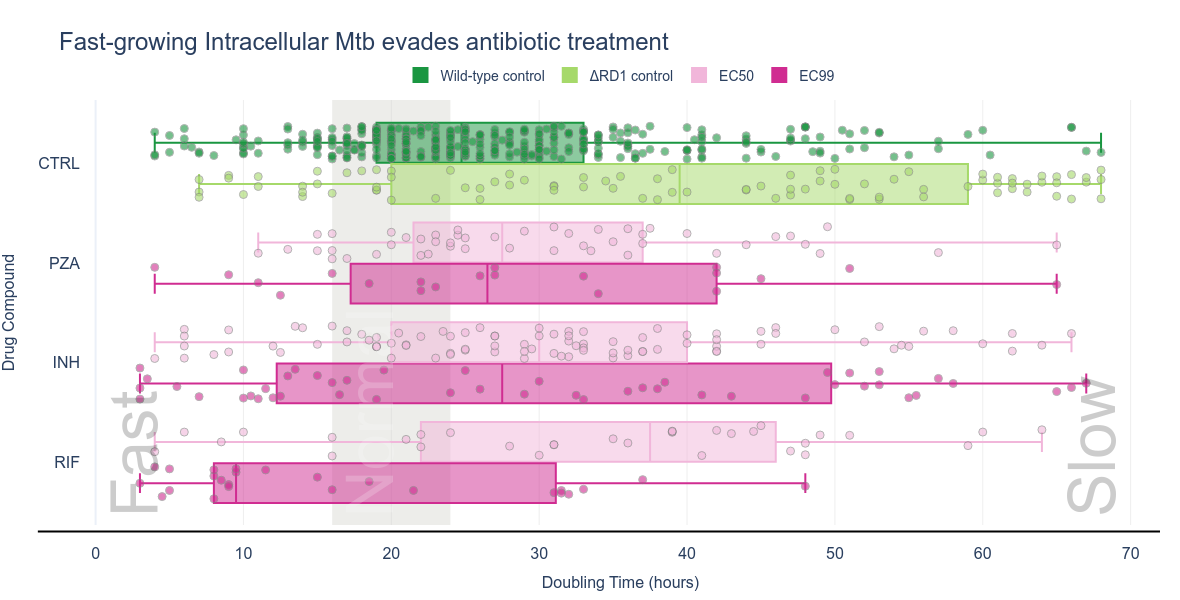

In [24]:


# Create the Plotly figure
fig = go.Figure()

# Add shaded regions
fig.add_shape(type="rect", xref="x", yref="paper", x0=0, x1=bins[1], y0=0, y1=1, fillcolor=colors['Fast'], opacity=0.4, layer="below", line_width=0)
fig.add_shape(type="rect", xref="x", yref="paper", x0=bins[1], x1=bins[2], y0=0, y1=1, fillcolor=colors['Normal'], opacity=0.4, layer="below", line_width=0)
fig.add_shape(type="rect", xref="x", yref="paper", x0=bins[2], x1=70, y0=0, y1=1, fillcolor=colors['Slow'], opacity=0.4, layer="below", line_width=0)

# Add annotations for categories
fig.add_annotation(text="Fast", x=0, y=-0.85, textangle=270, showarrow=False, font=dict(size=65, color="rgba(0, 0, 0, 0.2)", family="Helvetica"), xanchor="left", yanchor="bottom")
fig.add_annotation(text="Normal", x=bins[1], y=-0.85, textangle=270, showarrow=False, font=dict(size=65, color="rgba(255, 255, 255, 0.2)", family="Helvetica"), xanchor="left", yanchor="bottom")
fig.add_annotation(text="Slow", x=70, y=-0.85, textangle=270, showarrow=False, font=dict(size=65, color="rgba(0, 0, 0, 0.2)", family="Helvetica"), xanchor="right", yanchor="bottom")

# Add boxplots and scatter points with jitter
for compound in ['CTRL', 'PZA', 'INH', 'RIF']:
    compound_data = subset_df[subset_df['Mtb Strain or Drug Compound'] == compound]
    concentrations = compound_data['Concentration'].unique()
    ctrl_types = compound_data['CTRL Type'].unique() if compound == 'CTRL' else [None]

    for ctrl_type in ctrl_types:
        ctrl_type_data = compound_data[compound_data['CTRL Type'] == ctrl_type] if ctrl_type else compound_data

        for concentration in concentrations:
            data = ctrl_type_data[ctrl_type_data['Concentration'] == concentration]

            if data.empty:
                continue

            # Define the color for the box and scatter points
            if compound == 'CTRL':
                color = colors.get(ctrl_type, 'gray')
            else:
                color = colors.get(concentration, 'gray')

            # Base numeric position for the compound
            base_y_position = category_mapping[compound]

            # Apply offsets
            y_position = base_y_position + vertical_offsets.get(ctrl_type, 0) + vertical_offsets.get(concentration, 0)

            # Add jitter for scatter points
            jitter = np.random.uniform(-vertical_offset*0.8, vertical_offset*0.8, size=len(data))
            
            # Add boxplot trace
            fig.add_trace(go.Box(
                x=data['Doubling Times'],
                y=[y_position] * len(data),
                name=f"{compound} - {ctrl_type or ''} - {concentration or ''}".strip(" - "),
                marker_color=color,
                boxmean=False,
                orientation="h",
                width=0.6,
                boxpoints=False,
                showlegend=False,
                hoverinfo='skip'  # Disable hover information for the box plot

            ))
            
            # Add scatter plot trace with video links in custom data
            fig.add_trace(go.Scatter(
                x=data['Doubling Times'],
                y=[y_position + jitter[i] for i in range(len(data))],
                mode="markers",
                name=f"{compound} {ctrl_type or ''} {'' if concentration == 'EC0' else concentration or ''}".strip(),
                marker=dict(color=color, size=8, opacity=0.6, line=dict(color='gray',  # Outline color
                                                                        width=1)),  # Outline thickness,
   
                customdata=data['Video Link'],  # Pass video links via custom data
                hoverinfo="text",
                text=[
                    f"<b>Doubling Time:</b> {x:.2f}<br><b>Treatment:</b>{compound} {ctrl_type or ''}{'' if concentration == 'EC0' else concentration or ''}<br>"
                    for x in data['Doubling Times']
                ],
                showlegend=False
            ))
# Add legend entries using a loop
for entry in legend_entries:
    fig.add_trace(go.Scatter(
        x=[None],
        y=[None],
        mode="markers",
        marker=dict(color=entry["color"], symbol="square", size=40, line=dict(color='white', width=0)),
        name=entry["name"],
    ))

# Update the y-axis
fig.update_yaxes(tickvals=[category_mapping[category] for category in categories], ticktext=categories)

# Update the layout
fig.update_layout(
        margin=dict(l=50, r=20, t=100, b=50),  # Adjust left, right, top, and bottom margins

    title=dict(
        text="Fast-growing Intracellular Mtb evades antibiotic treatment",
        font=dict(family="Helvetica", size=24, weight='bold')  # Title font set to Helvetica
    ),
    height=600,
    xaxis=dict(
            title=dict(
                text="Doubling Time (hours)",  # X-axis title text
                font=dict(family="Helvetica", size=16)  # X-axis label font set to Helvetica
        ),
    gridcolor='rgba(200,200,200,0.3)',  # Gridline color
    showline=True,  # Show the bottom axis line
    linecolor="white",  # Set the axis line to white to mimic spacing
    linewidth=15,       # Make the axis line thicker (creates a "gap" effect)
    mirror=False,       # Don't mirror the axis lines
    tickmode="linear",  # Ensure linear tick marks
    dtick=10,           # Set tick interval to 10
    tickfont=dict(family="Helvetica", size=16),  # Tick mark font set to Helvetica
    layer="above traces",  # Ensure axis stays above gridlines for clarity
),
    yaxis=dict(
        title=dict(
            text="Drug Compound",  # Y-axis title text
            font=dict(family="Helvetica", size=16)  # Y-axis label font set to Helvetica
        ),
        gridcolor='rgba(200,200,200,0.3)',  # Gridline color
        showline=False,  # Remove the left axis line
        showgrid=False,   # Remove horizontal gridlines
        tickfont=dict(family="Helvetica", size=16),  # Tick mark font set to Helvetica
    ),
    hovermode="closest",
    template="plotly_white",
    font=dict(
        family="Helvetica",  # Set default font for the entire figure
        size=14  # Default size for unspecified text elements
    ),
    legend_itemclick=False,  # Disable legend item click
    legend_itemdoubleclick=False,  # Disable legend item double-click
    legend=dict(
        orientation="h",  # Stack items horizontally
        yanchor="bottom",  # Anchor the legend at the bottom
        y=1.02,  # Position it just above the plot (slightly above 1.0)
        xanchor="center",  # Center the legend horizontally
        x=0.5  # Center the legend in the middle of the plot
    )
)

fig.add_shape(
    type="line",
    x0=-0.04,  # Start at the left edge of the plot
    x1=1,  # End at the right edge of the plot (relative to paper coordinates)
    xref="paper",  # Reference paper coordinates (0 to 1 range)
    y0=-0.015,  # Slightly below the x-axis
    y1=-0.015,  # Same as y0 to make it horizontal
    yref="paper",  # Reference paper coordinates
    line=dict(
        color="black",  # Black line for the pseudo x-axis
        width=2  # Adjust the thickness of the line
    ),
)

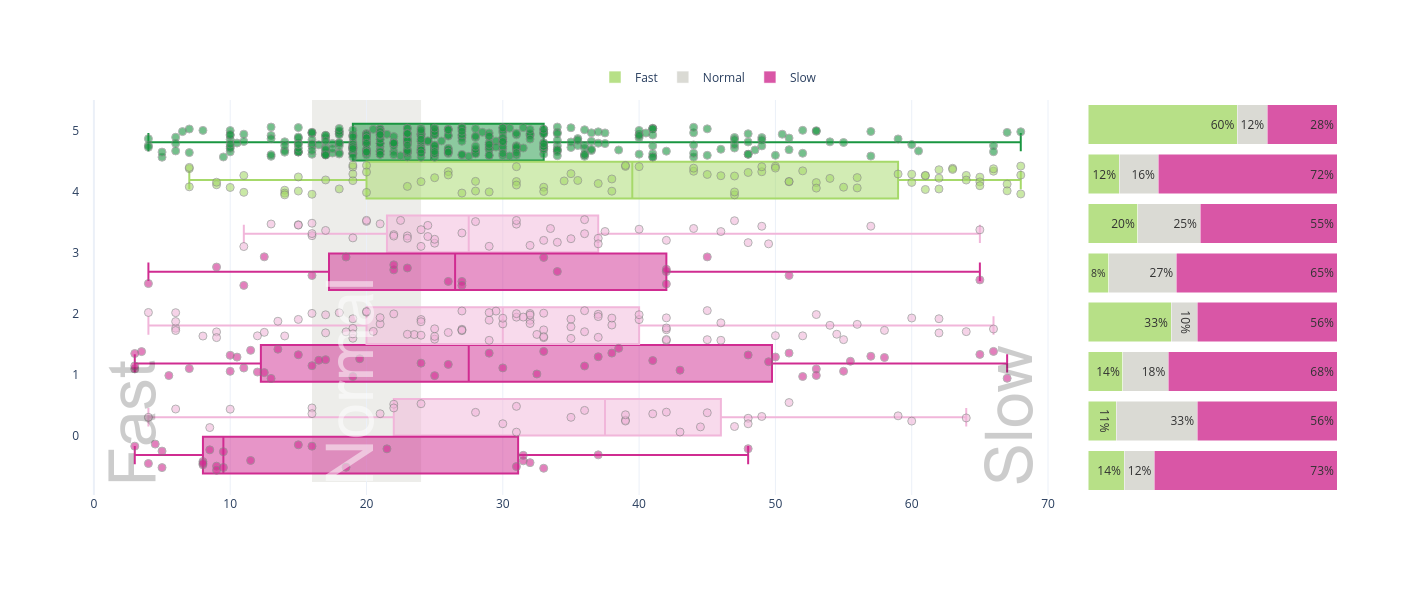

In [43]:
# Initialize the subplot figure
fig = make_subplots(
    rows=2, 
    cols=2,
    column_widths=[0.8, 0.2],
    row_heights=[0.95, 0.05],
    horizontal_spacing=0.01,
    vertical_spacing=0.01
)

# Add shaded region to the first subplot
fig.add_shape(
    type="rect", 
    x0=bins[1], x1=bins[2], 
    y0=-0.75, y1=5.5, 
    fillcolor=colors['Normal'], 
    opacity=0.4, 
    layer="below", 
    line_width=0,
    row=1, col=1
)
# Add annotations for categories
fig.add_annotation(text="Fast", x=0, y=-0.85, textangle=270, showarrow=False, font=dict(size=65, color="rgba(0, 0, 0, 0.2)", family="Helvetica"), xanchor="left", yanchor="bottom")
fig.add_annotation(text="Normal", x=bins[1], y=-0.85, textangle=270, showarrow=False, font=dict(size=65, color="rgba(255, 255, 255, 0.5)", family="Helvetica"), xanchor="left", yanchor="bottom")
fig.add_annotation(text="Slow", x=70, y=-0.85, textangle=270, showarrow=False, font=dict(size=65, color="rgba(0, 0, 0, 0.2)", family="Helvetica"), xanchor="right", yanchor="bottom")



# Add your existing boxplots and scatter points to the first subplot
for compound in ['CTRL', 'PZA', 'INH', 'RIF']:
    compound_data = subset_df[subset_df['Mtb Strain or Drug Compound'] == compound]
    concentrations = compound_data['Concentration'].unique()
    ctrl_types = compound_data['CTRL Type'].unique() if compound == 'CTRL' else [None]

    for ctrl_type in ctrl_types:
        ctrl_type_data = compound_data[compound_data['CTRL Type'] == ctrl_type] if ctrl_type else compound_data

        for concentration in concentrations:
            data = ctrl_type_data[ctrl_type_data['Concentration'] == concentration]

            if data.empty:
                continue

            # Your existing color logic
            if compound == 'CTRL':
                color = colors.get(ctrl_type, 'gray')
            else:
                color = colors.get(concentration, 'gray')

            base_y_position = category_mapping[compound]
            y_position = base_y_position + vertical_offsets.get(ctrl_type, 0) + vertical_offsets.get(concentration, 0)
            jitter = np.random.uniform(-vertical_offset*0.8, vertical_offset*0.8, size=len(data))

            # Add traces to first subplot
            fig.add_trace(
                go.Box(
                    x=data['Doubling Times'],
                    y=[y_position] * len(data),
                    name=f"{compound} - {ctrl_type or ''} - {concentration or ''}".strip(" - "),
                    marker_color=color,
                    boxmean=False,
                    orientation="h",
                    width=0.6,
                    boxpoints=False,
                    showlegend=False,
                    hoverinfo='skip'
                ),
                row=1, col=1
            )

            fig.add_trace(
                go.Scatter(
                    x=data['Doubling Times'],
                    y=[y_position + jitter[i] for i in range(len(data))],
                    mode="markers",
                    name=f"{compound} {ctrl_type or ''} {'' if concentration == 'EC0' else concentration or ''}".strip(),
                    marker=dict(
                        color=color, 
                        size=8, 
                        opacity=0.6, 
                        line=dict(color='gray', width=1)
                    ),
                    customdata=data['Video Link'],
                    hoverinfo="text",
                    text=[
                        f"<b>Doubling Time:</b> {x:.2f}<br><b>Treatment:</b>{compound} {ctrl_type or ''}{'' if concentration == 'EC0' else concentration or ''}<br>"
                        for x in data['Doubling Times']
                    ],
                    showlegend=False
                ),
                row=1, col=1
            )

# Add the proportions to the second subplot
categories = ['Fast', 'Normal', 'Slow']
colors_bar = [expanded_piyg[1], expanded_piyg[3], expanded_piyg[5]]

for i, (category, color) in enumerate(zip(categories, colors_bar)):
    fig.add_trace(
        go.Bar(
            x=combined_data[category],
            y=combined_data['Category'],
            name=category,
            orientation='h',
            marker_color=color,
            opacity=0.8,
            text=[f"{val:.0%}" if val > 0.05 else "" for val in combined_data[category]],
            textposition='inside',
            textfont=dict(color='black', size=12),
            showlegend=True,
            legendgroup=category,
        ),
        row=1, col=2
    )

# Update layout
fig.update_layout(
    # Your existing layout settings
    barmode='stack',
    template="plotly_white",
    height=600,
    showlegend=True,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    )
)

# Update axes
fig.update_xaxes(visible=False, range=[0, 1], row=1, col=2)
fig.update_yaxes(visible=False, row=1, col=2)

fig.show()

In [16]:
html_template = f"""
<!DOCTYPE html>
<html>
<head>
    <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
    <style>
        .container {{
            margin: 0 auto;
        }}
        #plot {{
            height: 10vh;
        }}
        .hover-popup {{
            position: absolute;
            background-color: white;
            border: 2px solid white;
            padding: 5px;
            z-index: 1000;
            display: none;
            box-shadow: 0 2px 10px rgba(0,0,0,0.1);
        }}
    </style>
</head>
<body>
    <div class="container">
        <div id="plot"></div>
        <div id="hover-popup" class="hover-popup">
            <video id="popup-video" 
                   style="width: 400px; height: 400px; object-fit: cover; object-position: center top;" 
                   autoplay loop muted playsinline>
            </video>
        </div>
    </div>
    <script>
        // Load the Plotly figure
        const figure = {fig.to_json()};
        
        // Initialize the plot
        Plotly.newPlot('plot', figure.data, figure.layout);
        
        const hoverPopup = document.getElementById('hover-popup');
        const popupVideo = document.getElementById('popup-video');
        
        // Add hover event listener for plot
        document.getElementById('plot').on('plotly_hover', function(eventData) {{
            const point = eventData.points[0];
            const videoUrl = point.customdata;
            
            if (videoUrl) {{
                // Update video source and show popup
                popupVideo.src = videoUrl;
                hoverPopup.style.display = 'block';
                
                // Position the popup near the cursor
                const hoverWidth = hoverPopup.offsetWidth;
                hoverPopup.style.left = `${{eventData.event.clientX - hoverWidth/2}}px`;
                hoverPopup.style.top = `${{eventData.event.clientY + 20}}px`;
            }}
        }});
        
        // Hide popup on unhover
        document.getElementById('plot').on('plotly_unhover', function() {{
            hoverPopup.style.display = 'none';
            popupVideo.pause();
        }});
    </script>
</body>
</html>
"""

# Save the plot to an HTML file with added video functionality
output_file = "interactive_plots/F4.html"

# Write the HTML file
with open(output_file, "w") as f:
    f.write(html_template)

print(f"Interactive plot with video hover saved to {output_file}")
# Open in browser
webbrowser.open('file://' + os.path.realpath(output_file))

Interactive plot with video hover saved to interactive_plots/F4.html


True

### Save out the html to the main webpage

In [45]:

# Save the plot to an HTML file with added video functionality
output_file = "../docs/figures/F4.html"

# Write the HTML file
with open(output_file, "w") as f:
    f.write(html_template)

print(f"Interactive plot with video hover saved to {output_file}")
# Open in browser
webbrowser.open('file://' + os.path.realpath(output_file))

Interactive plot with video hover saved to ../docs/figures/F4.html


True